# House Price Prediction using Linear Regression

## Simple Regression Model

**Internship:** CodeOrbit Tech  
**Role:** Machine Learning Intern  
**Submitted by:** Tabassum Gulnar  
**Project:** 3 — Regression Model for Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== DUPLICATE RECORDS =====")
print(df.duplicated().sum())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

===== MISSING VALUES =====
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

===== DUPLICATE RECORDS =====
0


## Data Preprocessing

The dataset was checked for missing values and duplicate records.

The target variable is `MedHouseVal`, which represents the median house value.

In [4]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features:")
print(X.columns.tolist())

print("\nTarget Variable: MedHouseVal")

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target Variable: MedHouseVal


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 16512
Testing Records: 4128


## Linear Regression Model

A Linear Regression model is used to predict house values based on the available housing features.

In [6]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [7]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values[:10],
    "Predicted Price": y_pred[:10]
})

display(comparison)

,Actual Price,Predicted Price
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Model Evaluation

The model is evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.

In [8]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


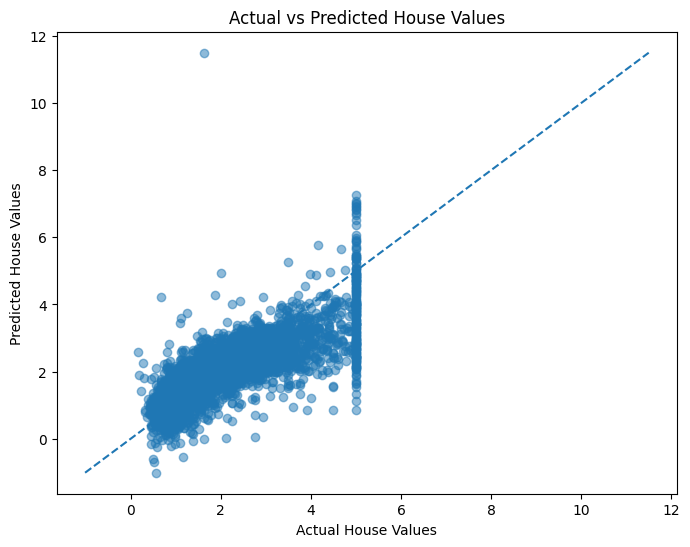

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")

plt.show()

In [10]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient,Absolute Coefficient
3,AveBedrms,0.783145,0.783145
0,MedInc,0.448675,0.448675
7,Longitude,-0.433708,0.433708
6,Latitude,-0.419792,0.419792
2,AveRooms,-0.123323,0.123323
1,HouseAge,0.009724,0.009724
5,AveOccup,-0.003526,0.003526
4,Population,-0.000002,0.000002


In [11]:
print("===== PROJECT 3 FINAL RESULTS =====")
print("Project: House Price Prediction")
print("Model: Linear Regression")
print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))
print("Number of Features:", X.shape[1])
print("MAE:", round(mae, 4))
print("MSE:", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R² Score:", round(r2, 4))

===== PROJECT 3 FINAL RESULTS =====
Project: House Price Prediction
Model: Linear Regression
Training Records: 16512
Testing Records: 4128
Number of Features: 8
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
R² Score: 0.5758


## Conclusion

The Linear Regression model was used to predict house values based on housing-related features.

The model was evaluated using MAE, MSE, RMSE, and R² Score. The actual and predicted values were also visualized to understand the model's prediction performance.

The project provided practical experience in regression modeling, train-test splitting, prediction, model evaluation, and data visualization.